In [9]:
import yfinance as yf
import pandas as pd
import numpy as np
import vectorbt as vbt
import matplotlib.pyplot as plt

In [2]:
data = yf.download("SPY", start="2025-10-01", end="2025-11-02", interval="30m", auto_adjust=True)
data.columns = data.columns.droplevel(1)
data

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Datetime,,,,,
2025-10-01 13:30:00+00:00,663.780029,665.390015,663.059998,663.169983,12573508
2025-10-01 14:00:00+00:00,665.530029,665.710022,663.409973,663.734985,5581163
2025-10-01 14:30:00+00:00,665.804993,666.059998,665.260010,665.530029,4697694
2025-10-01 15:00:00+00:00,666.309998,666.440002,665.750000,665.804993,3949027
2025-10-01 15:30:00+00:00,666.974976,667.179993,666.309998,666.309998,4228022
...,...,...,...,...,...
2025-10-31 17:30:00+00:00,680.869995,681.489990,679.429993,679.799988,3324655
2025-10-31 18:00:00+00:00,682.309998,682.440002,680.809998,680.859985,3920478
2025-10-31 18:30:00+00:00,682.614990,682.750000,681.729980,682.320007,3568668


In [3]:
n = 10 # Number of bars on each side to confirm a pivot
window_size = 2*n + 1

rolling_min = data['Low'].rolling(window=window_size, center=True).min()
rolling_max = data['High'].rolling(window=window_size, center=True).max()
data['is_pivot_low'] = (data['Low'] == rolling_min)
data['is_pivot_high'] = (data['High'] == rolling_max)

print(f"Found {data['is_pivot_low'].sum()} Pivot Lows")
print(f"Found {data['is_pivot_high'].sum()} Pivot Highs")

Found 11 Pivot Lows
Found 10 Pivot Highs


In [6]:
data['last_pivot_low_ts'] = data.index.where(data['is_pivot_low'])
data['last_pivot_high_ts'] = data.index.where(data['is_pivot_high'])

# Forward-fill the timestamps so every row knows the "most recent" pivot
data['last_pivot_low_ts'] = data['last_pivot_low_ts'].ffill()
data['last_pivot_high_ts'] = data['last_pivot_high_ts'].ffill()

# The regime is bullish if the last low is *newer* than the last high
data['is_bullish_regime'] = data['last_pivot_low_ts'] > data['last_pivot_high_ts']

# Generate signals
data['go_long'] = (data['is_bullish_regime'] == True) & (data['is_bullish_regime'].shift(1) == False)
data['close_long'] = (data['is_bullish_regime'] == False) & (data['is_bullish_regime'].shift(1) == True)

print(f"Found {data['go_long'].sum()} Buy Signals")
print(f"Found {data['close_long'].sum()} Sell Signals")


Found 9 Buy Signals
Found 8 Sell Signals


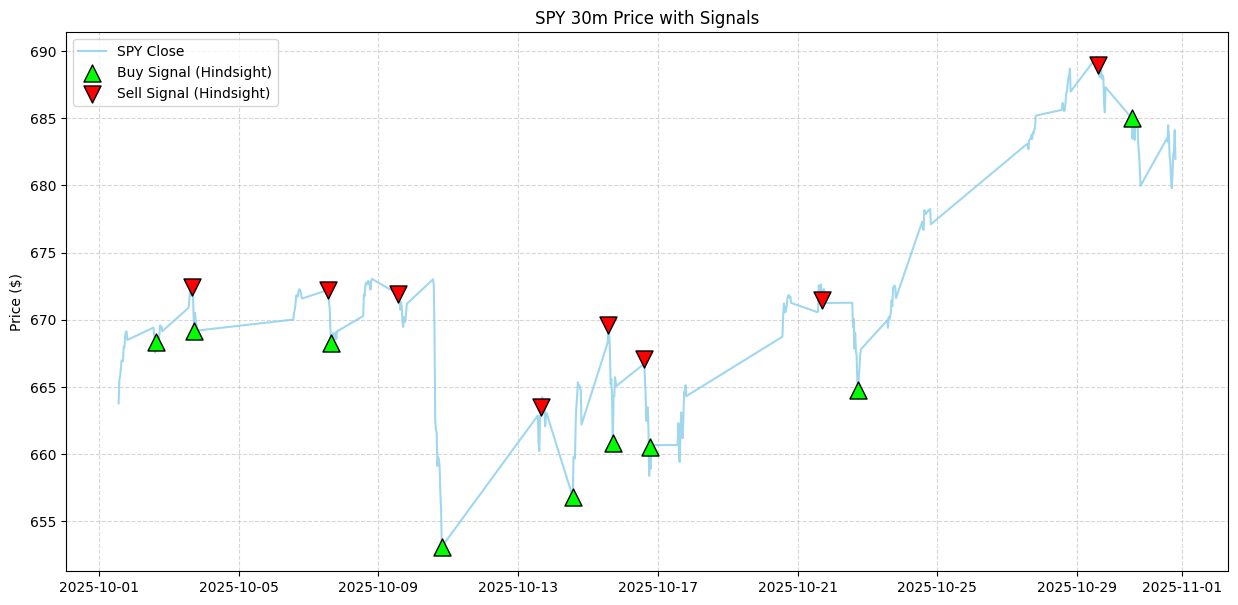

In [11]:
buy_signals = data[data["go_long"]]
sell_signals = data[data["close_long"]]

plt.figure(figsize=(15, 7))
plt.plot(data.index, data["Close"], label="SPY Close", color="skyblue", alpha=0.8)

# Plot the buy signals
plt.scatter(
    buy_signals.index,
    buy_signals["Close"],
    label="Buy Signal (Hindsight)",
    marker="^",
    color="lime",
    s=150,  # size
    edgecolor="black",
    zorder=3,  # plot on top
)

# Plot the sell signals
plt.scatter(
    sell_signals.index,
    sell_signals["Close"],
    label="Sell Signal (Hindsight)",
    marker="v",
    color="red",
    s=150,
    edgecolor="black",
    zorder=3,
)

plt.title('SPY 30m Price with Signals')
plt.ylabel("Price ($)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

*What problem do you immediately see with trying to trade this in real-time?*